In [1]:
# ============================================================
# 04 - Experiment 1: Feature Set Comparison
# ============================================================
# Owner: Peter Wilson
# Purpose: Train Random Forest four separate times using
#          URL-only, content-only, header-only, and all
#          features combined. Compare accuracy across each
#          to determine which feature category contributes
#          most to detection performance.
# ============================================================


In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from src.models import train_and_evaluate
from src.utils import load_splits

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = load_splits()

print("Splits loaded:", X_train.shape)
print("\nAll columns available:")
for i, col in enumerate(X_train.columns.tolist()):
    print(f"  {i}: {col}")

Splits loaded: (164484, 50)

All columns available:
  0: URLLength
  1: DomainLength
  2: IsDomainIP
  3: URLSimilarityIndex
  4: CharContinuationRate
  5: TLDLegitimateProb
  6: URLCharProb
  7: TLDLength
  8: NoOfSubDomain
  9: HasObfuscation
  10: NoOfObfuscatedChar
  11: ObfuscationRatio
  12: NoOfLettersInURL
  13: LetterRatioInURL
  14: NoOfDegitsInURL
  15: DegitRatioInURL
  16: NoOfEqualsInURL
  17: NoOfQMarkInURL
  18: NoOfAmpersandInURL
  19: NoOfOtherSpecialCharsInURL
  20: SpacialCharRatioInURL
  21: IsHTTPS
  22: LineOfCode
  23: LargestLineLength
  24: HasTitle
  25: DomainTitleMatchScore
  26: URLTitleMatchScore
  27: HasFavicon
  28: Robots
  29: IsResponsive
  30: NoOfURLRedirect
  31: NoOfSelfRedirect
  32: HasDescription
  33: NoOfPopup
  34: NoOfiFrame
  35: HasExternalFormSubmit
  36: HasSocialNet
  37: HasSubmitButton
  38: HasHiddenFields
  39: HasPasswordField
  40: Bank
  41: Pay
  42: Crypto
  43: HasCopyrightInfo
  44: NoOfImage
  45: NoOfCSS
  46: NoOfJS
  4

In [4]:
# These column groups are based on what each feature
# measures in the PhiUSIIL dataset

# URL structure and lexical features
url_features = [
    'URLLength', 'DomainLength', 'IsDomainIP',
    'URLSimilarityIndex', 'CharContinuationRate',
    'TLDLegitimateProb', 'URLCharProb', 'TLDLength',
    'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar',
    'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL',
    'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL',
    'NoOfQMarkInURL', 'NoOfAmpersandInURL',
    'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS'
]

# Page content and visual features
content_features = [
    'LineOfCode', 'LargestLineLength', 'HasTitle',
    'DomainTitleMatchScore', 'URLTitleMatchScore',
    'HasFavicon', 'IsResponsive', 'HasDescription',
    'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS'
]

# Header metadata and external reference features
header_features = [
    'Robots', 'NoOfURLRedirect', 'NoOfSelfRedirect',
    'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit',
    'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields',
    'HasPasswordField', 'Bank', 'Pay', 'Crypto',
    'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef'
]

feature_sets = {
    'URL-only':     url_features,
    'Content-only': content_features,
    'Header-only':  header_features,
    'All-features': url_features + content_features + header_features
}

print("Feature set sizes:")
for name, cols in feature_sets.items():
    print(f"  {name}: {len(cols)} features")

Feature set sizes:
  URL-only: 22 features
  Content-only: 12 features
  Header-only: 16 features
  All-features: 50 features


In [5]:
exp1_results = []

for set_name, cols in feature_sets.items():
    print(f"Training Random Forest on {set_name}...")
    results, _ = train_and_evaluate(
        RandomForestClassifier(n_estimators=100, random_state=489),
        f'exp1_{set_name}',
        X_train[cols], y_train,
        X_val[cols],   y_val
    )
    exp1_results.append(results)
    print(f"  Accuracy: {results['accuracy']:.4f}")
    print(f"  F1:       {results['f1']:.4f}\n")

exp1_df = pd.DataFrame(exp1_results)
exp1_df.to_csv('../results/experiment1_results.csv', index=False)

print("Experiment 1 complete")
print(exp1_df[['model','accuracy','precision','recall','f1']])

Training Random Forest on URL-only...
Model saved to results/exp1_URL-only.pkl
  Accuracy: 1.0000
  F1:       1.0000

Training Random Forest on Content-only...
Model saved to results/exp1_Content-only.pkl
  Accuracy: 0.9963
  F1:       0.9968

Training Random Forest on Header-only...
Model saved to results/exp1_Header-only.pkl
  Accuracy: 0.9906
  F1:       0.9918

Training Random Forest on All-features...
Model saved to results/exp1_All-features.pkl
  Accuracy: 1.0000
  F1:       1.0000

Experiment 1 complete
               model  accuracy  precision    recall        f1
0      exp1_URL-only  0.999972   0.999951  1.000000  0.999975
1  exp1_Content-only  0.996284   0.995513  0.998023  0.996766
2   exp1_Header-only  0.990583   0.992916  0.990658  0.991785
3  exp1_All-features  1.000000   1.000000  1.000000  1.000000


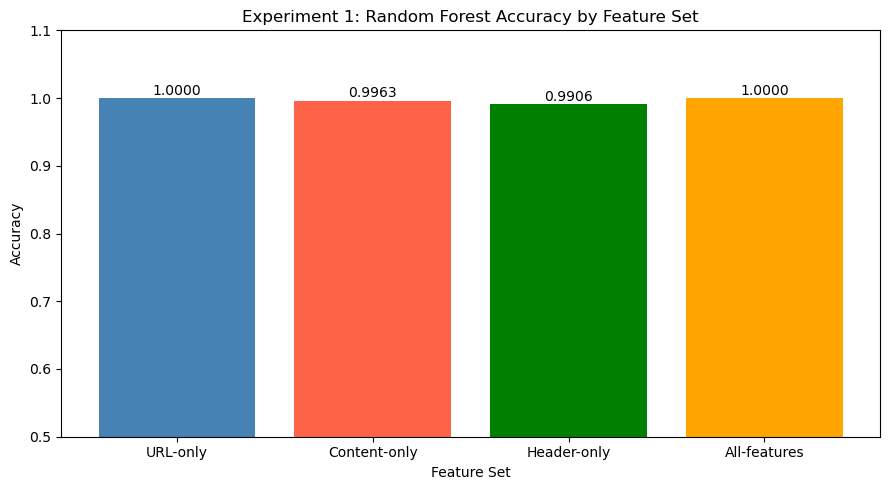

In [6]:
plt.figure(figsize=(9, 5))

colors = ['steelblue', 'tomato', 'green', 'orange']
bars = plt.bar(
    ['URL-only', 'Content-only', 'Header-only', 'All-features'],
    exp1_df['accuracy'],
    color=colors
)

# Add accuracy values on top of each bar
for bar, val in zip(bars, exp1_df['accuracy']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center', fontsize=10
    )

plt.title('Experiment 1: Random Forest Accuracy by Feature Set')
plt.ylabel('Accuracy')
plt.xlabel('Feature Set')
plt.ylim(0.5, 1.1)
plt.tight_layout()
plt.savefig('../results/figures/experiment1_accuracy.png', dpi=150)
plt.show()

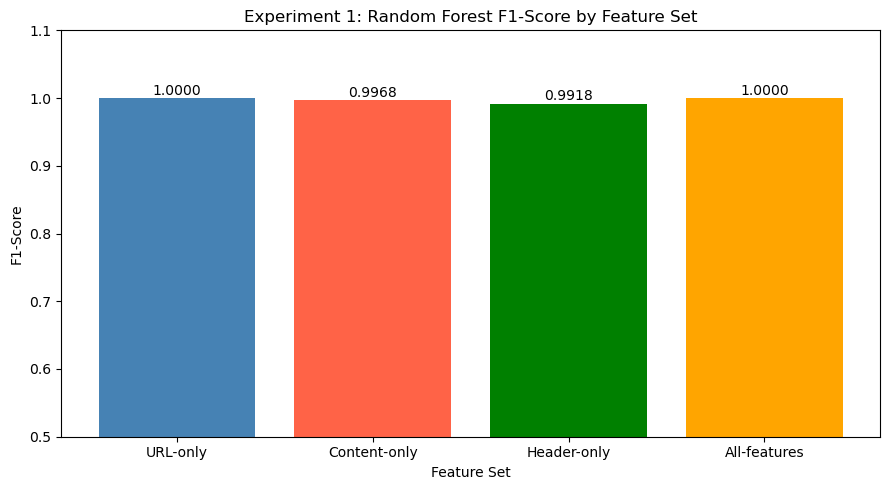

In [7]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    ['URL-only', 'Content-only', 'Header-only', 'All-features'],
    exp1_df['f1'],
    color=colors
)

for bar, val in zip(bars, exp1_df['f1']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center', fontsize=10
    )

plt.title('Experiment 1: Random Forest F1-Score by Feature Set')
plt.ylabel('F1-Score')
plt.xlabel('Feature Set')
plt.ylim(0.5, 1.1)
plt.tight_layout()
plt.savefig('../results/figures/experiment1_f1.png', dpi=150)
plt.show()